In [1]:
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

processor = RTDetrImageProcessor.from_pretrained("HuggingPanda/docling-layout")
model = RTDetrForObjectDetection.from_pretrained("HuggingPanda/docling-layout")
model.eval()

print(model.config.id2label)

preprocessor_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.86k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  172MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

{0: 'background', 1: 'Caption', 10: 'Text', 11: 'Title', 12: 'Document Index', 13: 'Code', 14: 'Checkbox-Selected', 15: 'Checkbox-Unselected', 16: 'Form', 17: 'Key-Value Region', 2: 'Footnote', 3: 'Formula', 4: 'List-item', 5: 'Page-footer', 6: 'Page-header', 7: 'Picture', 8: 'Section-header', 9: 'Table'}


In [3]:
import subprocess
print(subprocess.run("ls ~/doclaynet/", shell=True, capture_output=True, text=True).stdout)
print(subprocess.run("du -sh ~/doclaynet/*", shell=True, capture_output=True, text=True).stdout)

__MACOSX
COCO
data
DocLayNet_core.zip
PNG

4.0K	/Users/ahdithebomb/doclaynet/__MACOSX
634M	/Users/ahdithebomb/doclaynet/COCO
2.3G	/Users/ahdithebomb/doclaynet/data
 28G	/Users/ahdithebomb/doclaynet/DocLayNet_core.zip
 30G	/Users/ahdithebomb/doclaynet/PNG



In [4]:
import json, subprocess
from pathlib import Path

print(subprocess.run("ls ~/doclaynet/COCO/ && ls ~/doclaynet/PNG/ | head -3 && ls ~/doclaynet/PNG/ | wc -l",
                     shell=True, capture_output=True, text=True).stdout)

test.json
train.json
val.json
000000c264503f54eea3adfd8fabafe47248c76f7d688cb8f26b4d24876fccbe.png
0003579dd4c3ad0771c971afa45e38e60b3d21930113213974ed835198408e0b.png
00058abe155df18b34a492150ca9dac8da2f9904888abd40ac31d04e48899c47.png
   81471



In [6]:
from pathlib import Path
import json

DLN = Path.home() / "doclaynet"
val = json.load(open(DLN / "COCO" / "val.json"))

print("images:", len(val["images"]))
print("annotations:", len(val["annotations"]))
print("categories:", {c["id"]: c["name"] for c in val["categories"]})
print("image keys:", list(val["images"][0].keys()))

images: 6489
annotations: 99816
categories: {1: 'Caption', 2: 'Footnote', 3: 'Formula', 4: 'List-item', 5: 'Page-footer', 6: 'Page-header', 7: 'Picture', 8: 'Section-header', 9: 'Table', 10: 'Text', 11: 'Title'}
image keys: ['id', 'width', 'height', 'file_name', 'collection', 'doc_name', 'page_no', 'precedence', 'doc_category']


Counter({'manuals': 1853, 'financial_reports': 1745, 'laws_and_regulations': 1116, 'scientific_articles': 944, 'patents': 497, 'government_tenders': 334})
0.66s per page


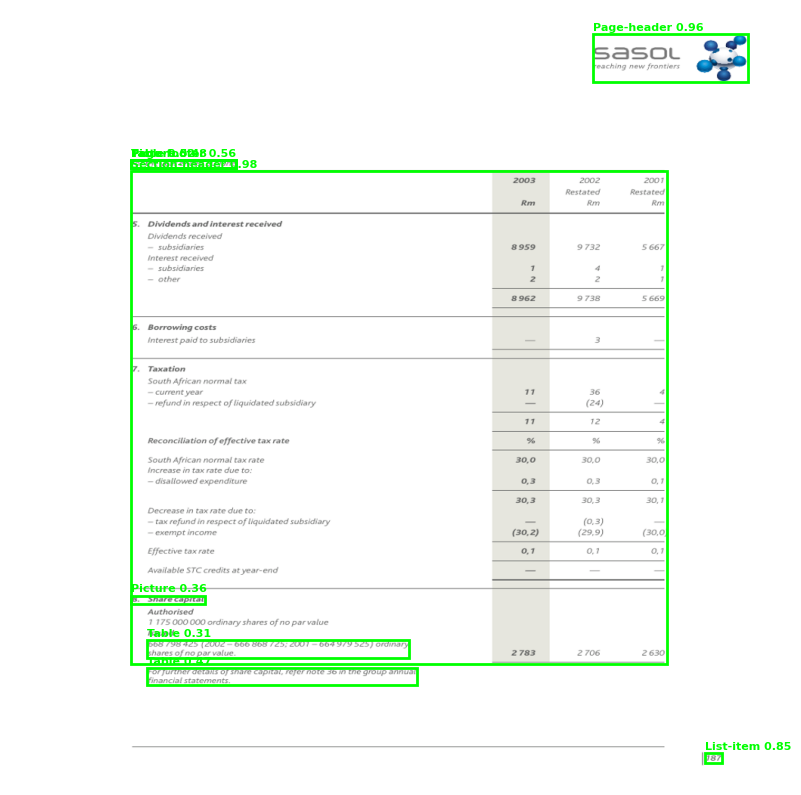

In [7]:
import torch, time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

print(Counter(im["doc_category"] for im in val["images"]))

img_path = DLN / "PNG" / val["images"][0]["file_name"]
image = Image.open(img_path).convert("RGB")

t = time.time()
inputs = processor(images=image, return_tensors="pt", size={"height": 640, "width": 640})
with torch.no_grad():
    outputs = model(**inputs)
res = processor.post_process_object_detection(
    outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.3
)[0]
print(f"{time.time()-t:.2f}s per page")

fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(image)
for score, label, box in zip(res["scores"], res["labels"], res["boxes"]):
    lid = label.item()
    x0, y0, x1, y1 = box.tolist()
    color = "lime" if lid <= 11 else "red"
    ax.add_patch(patches.Rectangle((x0, y0), x1-x0, y1-y0,
                 fill=False, edgecolor=color, linewidth=2))
    ax.text(x0, y0-4, f"{model.config.id2label[lid]} {score:.2f}",
            color=color, fontsize=8, weight="bold")
ax.axis("off")
plt.show()

In [8]:
import json, time, torch
from pathlib import Path
from PIL import Image
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

DLN = Path.home() / "doclaynet"
OUT = Path("results"); OUT.mkdir(exist_ok=True)

processor = RTDetrImageProcessor.from_pretrained("HuggingPanda/docling-layout")
model = RTDetrForObjectDetection.from_pretrained("HuggingPanda/docling-layout")
model.eval()

val = json.load(open(DLN / "COCO" / "val.json"))
preds, oos = [], []
t0 = time.time()

for i, im in enumerate(val["images"]):
    image = Image.open(DLN / "PNG" / im["file_name"]).convert("RGB")
    inputs = processor(images=image, return_tensors="pt",
                       size={"height": 640, "width": 640})
    with torch.no_grad():
        out = model(**inputs)
    r = processor.post_process_object_detection(
        out, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.05)[0]

    for s, l, b in zip(r["scores"], r["labels"], r["boxes"]):
        lid = int(l)
        x0, y0, x1, y1 = [float(v) for v in b]
        rec = {"image_id": im["id"], "category_id": lid,
               "bbox": [x0, y0, x1-x0, y1-y0], "score": float(s)}
        (preds if lid <= 11 else oos).append(rec)

    if i % 250 == 0:
        print(f"{i}/{len(val['images'])}  {time.time()-t0:.0f}s", flush=True)

json.dump(preds, open(OUT / "val_preds.json", "w"))
json.dump(oos, open(OUT / "val_out_of_schema.json", "w"))
print(f"done {time.time()-t0:.0f}s | in-schema {len(preds)} | out-of-schema {len(oos)}")

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

0/6489  0s
250/6489  80s
500/6489  160s
750/6489  242s
1000/6489  331s
1250/6489  415s
1500/6489  500s
1750/6489  585s
2000/6489  669s
2250/6489  751s
2500/6489  833s
2750/6489  915s
3000/6489  1001s
3250/6489  1086s
3500/6489  1174s
3750/6489  1254s
4000/6489  1338s
4250/6489  1419s
4500/6489  1502s
4750/6489  1586s
5000/6489  1666s
5250/6489  1746s
5500/6489  1828s
5750/6489  1909s
6000/6489  1989s
6250/6489  2070s
done 2152s | in-schema 1061145 | out-of-schema 192838


In [9]:
oos = json.load(open("results/val_out_of_schema.json"))
from collections import Counter
print(Counter(p["category_id"] for p in oos))
print(f"OOS rate: {len(oos)/(len(oos)+len(preds))*100:.1f}%")

Counter({16: 111729, 15: 33848, 12: 31931, 14: 13404, 13: 1926})
OOS rate: 15.4%


In [10]:
for t in (0.3, 0.5):
    o = sum(1 for p in oos if p["score"] >= t)
    i = sum(1 for p in preds if p["score"] >= t)
    print(f"thr {t}: OOS {o}/{o+i} = {100*o/(o+i):.1f}%")

thr 0.3: OOS 12092/209851 = 5.8%
thr 0.5: OOS 4972/132991 = 3.7%


In [14]:
import json, random, time, torch
from pathlib import Path
from PIL import Image
from collections import Counter
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

DLN = Path.home() / "doclaynet"
gt = COCO(str(DLN / "COCO" / "val.json"))
names = {c["id"]: c["name"] for c in gt.dataset["categories"]}

processor = RTDetrImageProcessor.from_pretrained("HuggingPanda/docling-layout")
model = RTDetrForObjectDetection.from_pretrained("HuggingPanda/docling-layout")
model.eval();
print("ready")

loading annotations into memory...
Done (t=0.29s)
creating index...
index created!


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

ready


In [15]:
# out-of-schema, corrected mapping
oos = json.load(open("results/val_oos_fixed.json"))
fixed = json.load(open("results/val_preds_fixed.json"))
print(Counter(names.get(p["category_id"], p["category_id"]) for p in oos))
for t in (0.05, 0.3, 0.5):
    o = sum(1 for p in oos if p["score"] >= t)
    i = sum(1 for p in fixed if p["score"] >= t)
    print(f"thr {t}: {o}/{o+i} = {100*o/(o+i):.1f}%")

Counter({17: 111729, 16: 33848, 13: 31931, 15: 13404, 12: 4192, 14: 1926})
thr 0.05: 197030/1253983 = 15.7%
thr 0.3: 12384/209851 = 5.9%
thr 0.5: 5170/132991 = 3.9%


In [16]:
tender = [im["id"] for im in gt.dataset["images"]
          if im["doc_category"] == "government_tenders"]
E.params.imgIds = sorted(tender)
E.evaluate(); E.accumulate(); E.summarize()

NameError: name 'E' is not defined

In [17]:
dt = gt.loadRes(json.load(open("results/val_preds_fixed.json")))

# full val
E = COCOeval(gt, dt, "bbox")
E.evaluate(); E.accumulate(); E.summarize()

rows = []
for i, cid in enumerate(gt.getCatIds()):
    ap = E.eval["precision"][:, :, i, 0, 2]
    ap = ap[ap > -1].mean() if (ap > -1).any() else float("nan")
    rows.append((names[cid], round(ap*100, 1), len(gt.getAnnIds(catIds=[cid]))))
print("\n--- FULL VAL ---")
for n, ap, cnt in sorted(rows, key=lambda r: -r[1]):
    print(f"{n:<16} {ap:>6} {cnt:>7}")

# government_tenders only, fresh object so the full-val numbers stay intact
tender = sorted(im["id"] for im in gt.dataset["images"]
                if im["doc_category"] == "government_tenders")
Et = COCOeval(gt, dt, "bbox")
Et.params.imgIds = tender
Et.evaluate(); Et.accumulate(); Et.summarize()

rows_t = []
for i, cid in enumerate(gt.getCatIds()):
    ap = Et.eval["precision"][:, :, i, 0, 2]
    ap = ap[ap > -1].mean() if (ap > -1).any() else float("nan")
    rows_t.append((names[cid], round(ap*100, 1)))
print(f"\n--- GOVERNMENT_TENDERS ({len(tender)} pages) ---")
for n, ap in sorted(rows_t, key=lambda r: -r[1]):
    print(f"{n:<16} {ap:>6}")

Loading and preparing results...
DONE (t=0.86s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=23.31s).
Accumulating evaluation results...
DONE (t=4.39s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.511
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.777
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.513
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.255
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.406
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.611
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.302
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.637
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.691
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [18]:
from collections import Counter
tset = set(tender)
tc = Counter(a["category_id"] for a in gt.dataset["annotations"]
             if a["image_id"] in tset)

import csv
full = dict((n, ap) for n, ap, _ in rows)
fullc = {names[c]: len(gt.getAnnIds(catIds=[c])) for c in gt.getCatIds()}

with open("results/per_class_val_vs_tenders.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["class", "ap_full", "n_full", "ap_tenders", "n_tenders", "delta"])
    for n, apt in rows_t:
        cid = [k for k, v in names.items() if v == n][0]
        w.writerow([n, full[n], fullc[n], apt, tc.get(cid, 0),
                    round(apt - full[n], 1)])

print(open("results/per_class_val_vs_tenders.csv").read())

class,ap_full,n_full,ap_tenders,n_tenders,delta
Caption,66.4,1763,34.9,5,-31.5
Footnote,36.6,312,78.8,46,42.2
Formula,53.6,1894,30.3,9,-23.3
List-item,62.4,13320,69.2,993,6.8
Page-footer,21.9,5571,57.7,346,35.8
Page-header,39.4,6683,49.2,501,9.8
Picture,69.1,2775,53.0,108,-16.1
Section-header,48.4,15744,55.4,793,7.0
Table,77.9,2269,55.2,180,-22.7
Text,73.6,49186,79.0,2212,5.4
Title,13.0,299,8.4,22,-4.6

